# Files for unit test

In [2]:
import numpy as np
import healpy as hp
import astropy.units as u

from histpy import Histogram

from cosipy import test_data
from cosipy.image_deconvolution import CoordsysConversionMatrix, SpacecraftAttitudeExposureTable, AllSkyImageModel, DataIF_COSI_DC2
from cosipy.spacecraftfile import SpacecraftFile

from cosipy.response import FullDetectorResponse

In [2]:
nside = 1

In [3]:
ori = SpacecraftFile.open(test_data.path / "20280301_first_10sec.ofits")
ori

# Exposure Table

In [4]:
nside = 1

exposure_table = SpacecraftAttitudeExposureTable.from_orientation(ori, nside=nside, start=ori.get_time()[0], stop=ori.get_time()[-1], min_exposure=0, min_num_pointings=1)

exposure_table

  0%|          | 0/10 [00:00<?, ?it/s]

,scatt_binning_index,healpix_index_z_pointing,healpix_index_x_pointing,zpointing,xpointing,zpointing_averaged,xpointing_averaged,earth_zenith,altitude,livetime,total_livetime,num_pointings
0,0,2,0,"[[221.85821768724892, 16.850922533290632], [22...","[[41.85821768724894, 73.14907746670937], [41.8...","[221.9664686678809, 17.0934431047055]","[41.9671338956935, 72.90658036427057]","[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",10.0,10


In [5]:
exposure_table.to_pickle(test_data.path / "image_deconvolution" / "exposure_table_test_nside1_ring.pickle")

In [6]:
exposure_table.save_as_fits(test_data.path / "image_deconvolution" / "exposure_table_test_nside1_ring.fits", overwrite=True)

In [7]:
map_pointing_zx = exposure_table.calc_pointing_trajectory_map()

In [8]:
map_pointing_zx.write(test_data.path / "image_deconvolution" / "map_pointing_zx_test_nside1_ring.hdf5", overwrite=True)

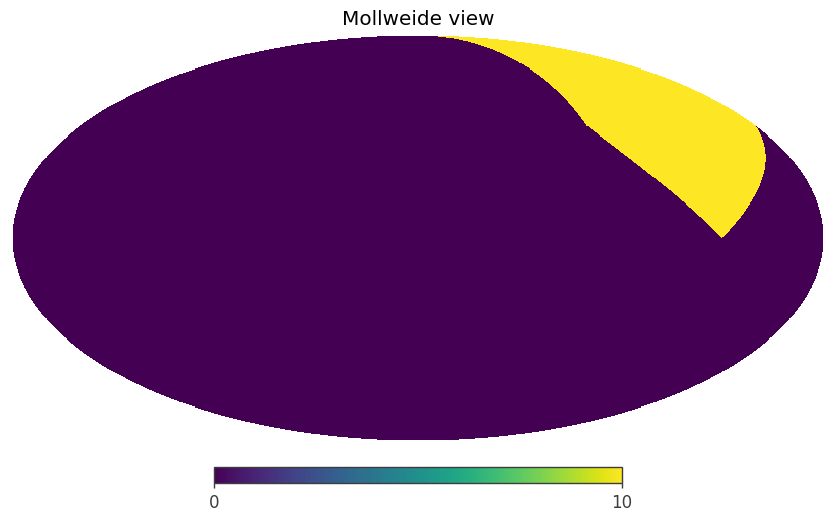

In [9]:
hp.mollview(map_pointing_zx.contents[:,0].todense())

# CoordsysConversionMatrix using time bins

In [10]:
full_detector_response = FullDetectorResponse.open(test_data.path / "test_full_detector_response.h5")

In [11]:
full_detector_response

FILENAME: '/Users/yoneda/Work/Exp/COSI/cosipy-2/soft/cosipy/cosipy/test_data/test_full_detector_response.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 12
    NSIDE: 1
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 30
    EDGES: [0.0 deg, 6.0 deg, 12.0 deg, 18.0 deg, 24.0 deg, 30.0 deg, 36.0 deg, 42.0 deg, 48.0 deg, 54.0 deg, 60.0 deg, 66.0 deg, 72.0 deg, 78.0 deg, 

In [12]:
#ccm = CoordsysConversionMatrix.time_binning_ccm(full_detector_response, ori, [ori.get_time()[0].value, ori.get_time()[-1].value] * u.s)

In [13]:
#ccm.axes['Time'].edges

In [14]:
#ccm.write(test_data.path / "image_deconvolution" / 'ccm_time_test.hdf5', overwrite=True)

# CoordsysConversionMatrix using ScAtt bins

In [17]:
ccm = CoordsysConversionMatrix.from_exposure_table(exposure_table, full_detector_response)

  0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
ccm_use_averaged_pointing = CoordsysConversionMatrix.from_exposure_table(exposure_table, full_detector_response, use_averaged_pointing = True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
ccm.write(test_data.path / "image_deconvolution" / 'ccm_scatt_use_averaged_pointing_False_test.hdf5', overwrite=True)

In [20]:
ccm_use_averaged_pointing.write(test_data.path / "image_deconvolution" / 'ccm_scatt_use_averaged_pointing_True_test.hdf5', overwrite=True)

# AllSkyImageModel

In [21]:
model = AllSkyImageModel(nside = nside, energy_edges = [100.0, 1000.0] * u.keV)
model[:] = 1.0 / u.s / u.sr / u.cm**2

In [22]:
model.write(test_data.path / "image_deconvolution" / 'all_sky_image_model_test_nside1.hdf5', overwrite=True)

# Histogram in ScAtt Binning

In [23]:
from cosipy import response
from cosipy import test_data
from cosipy import BinnedData
from histpy import Histogram, Axes, Axis, HealpixAxis
from scoords import Attitude, SpacecraftFrame
from astropy.coordinates import SkyCoord, ICRS, Galactic, FK4, FK5
import astropy.units as u
import numpy as np
import healpy as hp

In [24]:
full_detector_response = response.FullDetectorResponse.open(test_data.path / "test_full_detector_response.h5")
full_detector_response

FILENAME: '/Users/yoneda/Work/Exp/COSI/cosipy-2/soft/cosipy/cosipy/test_data/test_full_detector_response.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 12
    NSIDE: 1
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 30
    EDGES: [0.0 deg, 6.0 deg, 12.0 deg, 18.0 deg, 24.0 deg, 30.0 deg, 36.0 deg, 42.0 deg, 48.0 deg, 54.0 deg, 60.0 deg, 66.0 deg, 72.0 deg, 78.0 deg, 

In [25]:
analysis = BinnedData(test_data.path / "inputs_crab.yaml")
analysis

In [26]:
analysis.energy_bins = full_detector_response.axes['Em'].edges.to(u.keV).value
analysis.nside = full_detector_response.axes['PsiChi'].nside

assert np.all(full_detector_response.axes['Phi'].widths == full_detector_response.axes['Phi'].widths[0]) == True

analysis.phi_pix_size = full_detector_response.axes['Phi'].widths[0].to(u.deg).value

analysis.time_bins = 10 #s

In [27]:
analysis.cosi_dataset = analysis.get_dict_from_hdf5(test_data.path / "unbinned_data_MEGAlib_calc.hdf5")

In [28]:
# NOTE: test_data.path / "unbinned_data_MEGAlib_calc.hdf5" is written in a old format!!!

_ = analysis.cosi_dataset.pop('Xpointings')
analysis.cosi_dataset['Xpointings (glon,glat)'] = _

_ = analysis.cosi_dataset.pop('Ypointings')
analysis.cosi_dataset['Ypointings (glon,glat)'] = _

_ = analysis.cosi_dataset.pop('Zpointings')
analysis.cosi_dataset['Zpointings (glon,glat)'] = _

In [29]:
binned_signal = exposure_table.get_binned_data_scatt(analysis, psichi_binning = 'local', sparse = False)

In [30]:
binned_signal.write(test_data.path / "image_deconvolution" / 'test_event_histogram_localCDS_scatt.h5', overwrite=True)

In [31]:
test_hist = Histogram.open(test_data.path / "image_deconvolution" / 'test_event_histogram_localCDS_scatt.h5')

In [32]:
binned_signal == test_hist

True

In [33]:
binned_signal

In [34]:
binned_signal

In [35]:
np.all(binned_signal.contents == test_hist.contents)

True

In [36]:
binned_signal.nbins

array([ 1, 10, 30, 12])

# Time+Local

In [5]:
import numpy as np
import astropy.units as u
from astropy.time import Time
from histpy import Histogram

from cosipy import test_data
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, TimeBinnedExposureTable
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import response
from cosipy import BinnedData

ori = SpacecraftFile.open(test_data.path / "20280301_first_10sec.fits")

tstart_list = Time([1835478000.0], scale='utc', format='unix')
tstop_list  = Time([1835478005.0], scale='utc', format='unix')

exposure_table = TimeBinnedExposureTable.from_orientation(ori, tstart_list = tstart_list, tstop_list = tstop_list)
exposure_table.save_as_fits("exposure_table_test_time_binning.fits")

full_detector_response = response.FullDetectorResponse.open(test_data.path / "test_full_detector_response.h5")

analysis = BinnedData(test_data.path / "inputs_crab.yaml")

analysis.cosi_dataset = analysis.get_dict_from_hdf5(test_data.path / "unbinned_data_MEGAlib_calc.hdf5")

# modify the following parameters for unit test
analysis.energy_bins = full_detector_response.axes['Em'].edges.to(u.keV).value
analysis.nside = full_detector_response.axes['PsiChi'].nside
analysis.phi_pix_size = full_detector_response.axes['Phi'].widths[0].to(u.deg).value
analysis.time_bins = 10 #s

# NOTE: test_data.path / "unbinned_data_MEGAlib_calc.hdf5" is written in a old format!!!
_ = analysis.cosi_dataset.pop('Xpointings')
analysis.cosi_dataset['Xpointings (glon,glat)'] = _

_ = analysis.cosi_dataset.pop('Ypointings')
analysis.cosi_dataset['Ypointings (glon,glat)'] = _

_ = analysis.cosi_dataset.pop('Zpointings')
analysis.cosi_dataset['Zpointings (glon,glat)'] = _

binned_signal = exposure_table.get_binned_data(analysis, psichi_binning = 'local', sparse = False)

This method assumes that TimeTags are sorted in ascending order.
This method assumes that TimeTags have the same time format ('unix') and scale ('utc') as tstart/tstop in the exposure table.


In [7]:
binned_signal.write('test_event_histogram_localCDS_time.h5', overwrite = True)